## 1. Import Libraries & Load Dataset

**Tujuan:** Memuat data hasil persiapan modeling (`X_train`, `X_test`, `y_train`, `y_test`) dari NB08, beserta library yang dibutuhkan untuk training dan evaluasi Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, recall_score, precision_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")

X_train: (4075, 8) | y_train: (4075,)
X_test : (1019, 8) | y_test : (1019,)


**Insight:** Data yang sama persis dengan NB09 berhasil dimuat (X_train: 4.075×8, X_test: 1.019×8) — memakai data preparation yang sama, supaya perbandingan Random Forest vs Logistic Regression nanti di NB11 adil (sama-sama belajar dari data yang identik).

## 2. Cek Multikolinearitas (VIF)

**Tujuan:** Mengecek secara formal apakah ada fitur yang saling tumpang tindih (redundan) menggunakan Variance Inflation Factor (VIF) — pengecekan standar sebelum regresi linear/logistik. Ini melengkapi correlation matrix di NB06 (yang cuma cek korelasi antar 2 fitur sekaligus) dengan metode yang mempertimbangkan hubungan SEMUA fitur secara bersamaan.

In [3]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data['Fitur'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['Fitur'] != 'const'].sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

                         Fitur      VIF
   smoking_status_never smoked 1.583195
smoking_status_formerly smoked 1.506797
                           age 1.442982
         smoking_status_smokes 1.377507
                           bmi 1.162734
                  hypertension 1.102591
                 heart_disease 1.099061
             avg_glucose_level 1.091689


**Insight:** Seluruh fitur menunjukkan nilai VIF di rentang 1,09–1,58, jauh di bawah ambang batas 5 yang umum dijadikan patokan multikolinearitas bermasalah. Hasil ini konsisten dengan temuan correlation matrix pada NB06 (korelasi tertinggi hanya ~0,32), sekaligus memvalidasi ulang keputusan NB05 untuk membuang `ever_married` dan `work_type` karena berpotensi menjadi proxy dari `age` — terbukti dengan VIF `age` yang tetap rendah (1,44) setelah kedua fitur tersebut dihilangkan. Tidak diperlukan penanganan tambahan (seperti membuang fitur atau regularisasi khusus) untuk mengatasi multikolinearitas; koefisien Logistic Regression pada model final dapat diinterpretasikan dengan aman.

## 3. Feature Scaling

**Tujuan:** Menyamakan skala seluruh fitur menggunakan StandardScaler, sebelum masuk ke Logistic Regression.

**Kenapa ini WAJIB untuk Logistic Regression, tapi TIDAK untuk Random Forest (NB09):** Random Forest bekerja berbasis threshold per fitur secara independen — nggak peduli `age` rentangnya 0-82 sementara `hypertension` cuma 0-1. Tapi Logistic Regression itu model berbasis perhitungan jarak/gradien — kalau dibiarkan beda skala jauh, model bisa salah "mengira" `age` lebih berpengaruh cuma karena angkanya besar, bukan karena beneran lebih penting secara statistik.

**Prinsip krusial (sama seperti train-test split di NB08):** scaler hanya boleh "belajar" (fit) dari `X_train`, lalu diterapkan (transform) ke `X_train` maupun `X_test`. `X_test` TIDAK BOLEH ikut proses fit — kalau ikut, itu data leakage (informasi dari data testing "bocor" ke proses persiapan sebelum model dievaluasi).

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Statistik X_train SEBELUM scaling:")
print(X_train.describe().loc[['mean', 'std']].round(2))

print("\nStatistik X_train SESUDAH scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(2))

Statistik X_train SEBELUM scaling:
        age  avg_glucose_level    bmi  hypertension  heart_disease  \
mean  43.19             105.89  28.85           0.1           0.05   
std   22.58              44.96   7.66           0.3           0.23   

      smoking_status_formerly smoked  smoking_status_never smoked  \
mean                            0.17                         0.38   
std                             0.37                         0.49   

      smoking_status_smokes  
mean                   0.15  
std                    0.35  

Statistik X_train SESUDAH scaling:
      age  avg_glucose_level  bmi  hypertension  heart_disease  \
mean -0.0               -0.0 -0.0          -0.0           -0.0   
std   1.0                1.0  1.0           1.0            1.0   

      smoking_status_formerly smoked  smoking_status_never smoked  \
mean                             0.0                          0.0   
std                              1.0                          1.0   

      smoking

**Insight:** Seluruh fitur berhasil di-scaling, dengan mean mendekati 0 dan standar deviasi mendekati 1 di semua kolom X_train — mengonfirmasi skala antar fitur (misal `age` yang tadinya berkisar 0-82 vs `hypertension` yang cuma 0-1) sekarang setara. Scaler di-fit HANYA dari X_train dan diterapkan ke X_test tanpa fit ulang, mencegah data leakage.

## 4. Inisialisasi & Training Model

**Tujuan:** Membuat model Logistic Regression dengan `class_weight='balanced'` (konsisten dengan pendekatan NB09), lalu melatihnya menggunakan data training yang sudah di-scaling.

In [5]:
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

print("Model berhasil dilatih.")
print(f"Jumlah fitur yang dipelajari: {log_model.n_features_in_}")
print(f"Jumlah iterasi sampai konvergen: {log_model.n_iter_[0]}")

Model berhasil dilatih.
Jumlah fitur yang dipelajari: 8
Jumlah iterasi sampai konvergen: 10


**Insight:** Logistic Regression berhasil dilatih menggunakan 8 fitur input yang sudah di-scaling, dengan `class_weight='balanced'` untuk menangani imbalance kelas — pendekatan yang sama seperti NB09, memastikan perbandingan kedua model nanti (NB11) menggunakan strategi imbalance-handling yang konsisten.

## 5. Prediksi ke Test Set

**Tujuan:** Menggunakan model Logistic Regression yang sudah dilatih untuk menebak status stroke pada data testing — sama seperti NB09, model hanya diberi fitur (`X_test_scaled`), tanpa jawaban aslinya.

In [6]:
y_pred_log = log_model.predict(X_test_scaled)

print(f"Jumlah prediksi: {len(y_pred_log)}")
print(f"\nDistribusi prediksi model:")
print(pd.Series(y_pred_log).value_counts())

print(f"\nDistribusi jawaban sebenarnya (y_test):")
print(y_test.value_counts())

Jumlah prediksi: 1019

Distribusi prediksi model:
0    705
1    314
Name: count, dtype: int64

Distribusi jawaban sebenarnya (y_test):
stroke
0    970
1     49
Name: count, dtype: int64


## 6. Evaluasi Model

**Tujuan:** Mengukur performa Logistic Regression pada threshold default (0,5) menggunakan Confusion Matrix, Recall, Precision, F1-Score — sama seperti NB09, untuk melihat titik awal sebelum threshold tuning.

Accuracy : 0.7262
Recall   : 0.8571
Precision: 0.1338
F1-Score : 0.2314


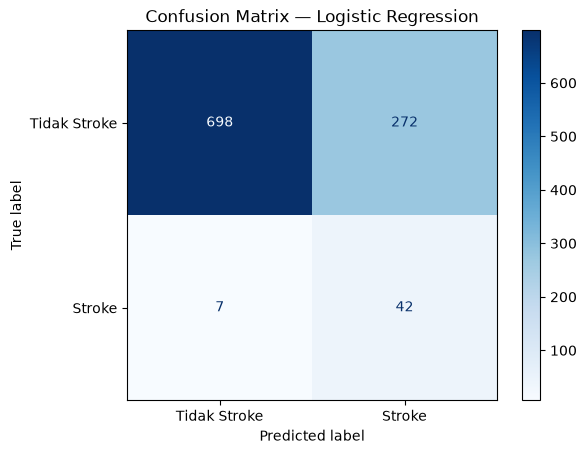

In [7]:
cm_log = confusion_matrix(y_test, y_pred_log)

accuracy_log = accuracy_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print(f"Accuracy : {accuracy_log:.4f}")
print(f"Recall   : {recall_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"F1-Score : {f1_log:.4f}")

disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Tidak Stroke', 'Stroke'])
disp_log.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Logistic Regression')
plt.savefig('../reports/figures/confusion_matrix_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Threshold Tuning

**Tujuan:** Mengecek apakah threshold default (0,5) benar-benar titik terbaik untuk Logistic Regression, atau ada titik lain yang menghasilkan keseimbangan recall-precision yang lebih baik — sama seperti yang dilakukan untuk Random Forest di NB09.

**Catatan:** LR di threshold default sudah menunjukkan recall tinggi (85,7%) — kemungkinan besar hasil terbaik ada di sekitar 0,5, bukan di titik serendah RF (0,2). Tetap dieksplorasi ke beberapa titik di kedua arah (naik maupun turun) untuk memastikan.

In [11]:
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]
thresholds = [0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

print(f"{'Threshold':<12}{'Recall':<10}{'Precision':<12}{'F1':<10}{'F2':<10}{'FN':<6}{'FP'}")
for t in thresholds:
    y_pred_t = (y_proba_log >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)
    f2 = (5 * p * r) / (4 * p + r) if (4*p + r) > 0 else 0
    fn = ((y_test==1) & (y_pred_t==0)).sum()
    fp = ((y_test==0) & (y_pred_t==1)).sum()
    print(f"{t:<12}{r:<10.3f}{p:<12.3f}{f1:<10.3f}{f2:<10.3f}{fn:<6}{fp}")

Threshold   Recall    Precision   F1        F2        FN    FP
0.7         0.694     0.198       0.308     0.462     15    138
0.6         0.816     0.175       0.289     0.472     9     188
0.5         0.857     0.134       0.231     0.412     7     272
0.4         0.898     0.112       0.200     0.374     5     348
0.3         0.918     0.097       0.176     0.341     4     418
0.2         0.959     0.083       0.152     0.307     2     522


**Keputusan Final Threshold: 0,6**

Dipilih karena F2-Score tertinggi (0,471) — metrik yang lebih merepresentasikan prioritas medis (recall diutamakan) dibanding F1. Pada threshold ini, recall tetap tinggi (81,6%, hanya 9 dari 49 kasus stroke kelewatan) dengan alarm palsu yang jauh lebih terkendali dibanding threshold default (188 vs 272).

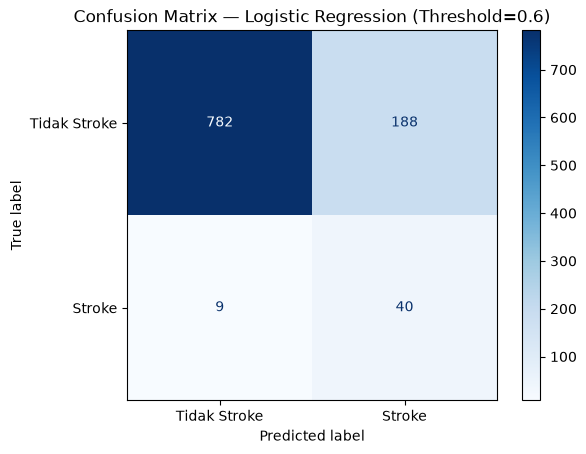

Recall   : 0.8163
Precision: 0.1754
F1-Score : 0.2888


In [12]:
FINAL_THRESHOLD_LOG = 0.6

y_pred_log_final = (y_proba_log >= FINAL_THRESHOLD_LOG).astype(int)

cm_log_final = confusion_matrix(y_test, y_pred_log_final)
disp_log_final = ConfusionMatrixDisplay(confusion_matrix=cm_log_final, display_labels=['Tidak Stroke', 'Stroke'])
disp_log_final.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix — Logistic Regression (Threshold={FINAL_THRESHOLD_LOG})')
plt.savefig('../reports/figures/confusion_matrix_logreg_final.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Recall   : {recall_score(y_test, y_pred_log_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_final):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_log_final):.4f}")

## 8. Interpretasi Koefisien

**Tujuan:** Melihat arah dan kekuatan pengaruh tiap fitur terhadap risiko stroke — kelebihan Logistic Regression yang tidak dimiliki Random Forest. `feature_importances_` di NB09 cuma bisa bilang "seberapa penting", TIDAK bisa bilang "menaikkan atau menurunkan risiko". Koefisien LR bisa jawab dua-duanya sekaligus.

**Kenapa interpretasi ini baru bisa dipercaya SEKARANG:** dua syarat sudah terpenuhi di section-section sebelumnya — (1) fitur sudah di-scaling (Section 3), jadi besar-kecilnya koefisien bisa dibandingkan adil antar fitur; (2) VIF sudah dicek aman (Section 2), jadi koefisien tidak terdistorsi oleh multikolinearitas.

In [13]:
coefficients = pd.DataFrame({
    'Fitur': X_train.columns,
    'Koefisien': log_model.coef_[0]
})
coefficients['Odds_Ratio'] = np.exp(coefficients['Koefisien'])
coefficients['Arah_Pengaruh'] = coefficients['Koefisien'].apply(lambda x: 'Menaikkan risiko' if x > 0 else 'Menurunkan risiko')
coefficients = coefficients.reindex(coefficients['Koefisien'].abs().sort_values(ascending=False).index)

print(coefficients.to_string(index=False))

                         Fitur  Koefisien  Odds_Ratio     Arah_Pengaruh
                           age   1.616671    5.036296  Menaikkan risiko
   smoking_status_never smoked  -0.157146    0.854579 Menurunkan risiko
             avg_glucose_level   0.154573    1.167160  Menaikkan risiko
                  hypertension   0.151577    1.163668  Menaikkan risiko
                 heart_disease   0.093504    1.098015  Menaikkan risiko
                           bmi   0.092505    1.096919  Menaikkan risiko
         smoking_status_smokes   0.052942    1.054369  Menaikkan risiko
smoking_status_formerly smoked  -0.022358    0.977890 Menurunkan risiko


**Insight:** `age` merupakan prediktor dominan (OR=5,04), jauh melampaui fitur lain — konsisten dengan hasil Random Forest (NB09) yang juga menempatkan `age` sebagai fitur terpenting. Seluruh fitur klinis (avg_glucose_level, hypertension, heart_disease, bmi) menunjukkan arah pengaruh yang sesuai dengan literatur medis (meningkatkan risiko stroke). Interpretasi pada kategori `smoking_status` perlu kehati-hatian karena kategori pembanding (baseline) yang terpilih secara otomatis melalui one-hot encoding adalah "Unknown" (bukan "never smoked"), sehingga odds ratio yang dilaporkan merepresentasikan perbandingan terhadap kelompok yang tidak mengungkapkan status merokoknya — bukan perbandingan langsung "merokok vs tidak merokok".

## 9. Perbandingan dengan SMOTE

**Tujuan:** Menguji secara empiris apakah SMOTE menghasilkan performa lebih baik dibanding `class_weight` + threshold-moving pada Logistic Regression — sama seperti eksperimen di NB09 untuk Random Forest.

In [19]:
smote = SMOTE(random_state=42)
X_train_scaled_smote, y_train_smote_log = smote.fit_resample(X_train_scaled, y_train)

print(f"Shape sebelum: {X_train_scaled.shape} | Shape sesudah: {X_train_scaled_smote.shape}")
print(f"\nDistribusi sesudah SMOTE:")
print(y_train_smote_log.value_counts())

Shape sebelum: (4075, 8) | Shape sesudah: (7756, 8)

Distribusi sesudah SMOTE:
stroke
0    3878
1    3878
Name: count, dtype: int64


**Insight:** Distribusi kelas berhasil diseimbangkan (3.878 vs 3.878, shape training naik dari 4.075 menjadi 7.756 baris) — proses yang identik dengan penerapan SMOTE pada Random Forest (NB09), menggunakan data yang sudah di-scaling (`X_train_scaled`) sesuai kebutuhan Logistic Regression.

=== Evaluasi Model SMOTE (threshold default 0,5) ===
Recall   : 0.8367
Precision: 0.1349
F1-Score : 0.2323


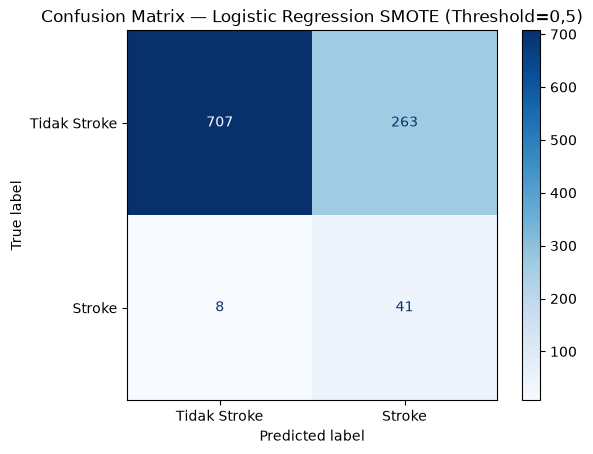

In [20]:
log_smote = LogisticRegression(random_state=42, max_iter=1000)  # TANPA class_weight
log_smote.fit(X_train_scaled_smote, y_train_smote_log)

y_pred_log_smote = log_smote.predict(X_test_scaled)

print(f"=== Evaluasi Model SMOTE (threshold default 0,5) ===")
print(f"Recall   : {recall_score(y_test, y_pred_log_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_smote):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_log_smote):.4f}")

cm_log_smote = confusion_matrix(y_test, y_pred_log_smote)
disp_log_smote = ConfusionMatrixDisplay(confusion_matrix=cm_log_smote, display_labels=['Tidak Stroke', 'Stroke'])
disp_log_smote.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Logistic Regression SMOTE (Threshold=0,5)')
plt.savefig('../reports/figures/confusion_matrix_logreg_smote.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Pada threshold default (0,5), model SMOTE menghasilkan Recall 83,67%, Precision 13,49%, F1-Score 0,2323 — nyaris identik dengan hasil `class_weight` pada threshold yang sama (Recall 85,71%, Precision 13,38%, F1-Score 0,2318).

In [15]:
y_proba_log_smote = log_smote.predict_proba(X_test_scaled)[:, 1]
thresholds = [0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

print(f"{'Threshold':<12}{'Recall':<10}{'Precision':<12}{'F1':<10}{'F2':<10}{'FN':<6}{'FP'}")
for t in thresholds:
    y_pred_t = (y_proba_log_smote >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)
    f2 = (5 * p * r) / (4 * p + r) if (4*p + r) > 0 else 0
    fn = ((y_test==1) & (y_pred_t==0)).sum()
    fp = ((y_test==0) & (y_pred_t==1)).sum()
    print(f"{t:<12}{r:<10.3f}{p:<12.3f}{f1:<10.3f}{f2:<10.3f}{fn:<6}{fp}")

Threshold   Recall    Precision   F1        F2        FN    FP
0.7         0.673     0.186       0.292     0.442     16    144
0.6         0.837     0.179       0.295     0.482     8     188
0.5         0.837     0.135       0.232     0.410     8     263
0.4         0.898     0.118       0.209     0.387     5     328
0.3         0.918     0.101       0.181     0.350     4     402
0.2         0.959     0.088       0.162     0.322     2     486


**Insight:** Pola trade-off yang sama seperti model `class_weight` teramati — F1 tertinggi di threshold 0,6 (0,295), F2 tertinggi juga di threshold 0,6 (0,482). Threshold optimal untuk SMOTE ternyata identik dengan threshold optimal `class_weight` (sama-sama 0,6), memudahkan perbandingan langsung pada tabel konsolidasi berikutnya.

### Tabel Perbandingan Konsolidasi: class_weight vs SMOTE

Menggabungkan hasil threshold tuning dari kedua model ke dalam satu tabel, menggunakan threshold yang identik untuk perbandingan yang adil.

In [17]:
thresholds = [0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

def hitung_metrik(y_true, y_proba, thresholds):
    hasil = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        r = recall_score(y_true, y_pred_t)
        p = precision_score(y_true, y_pred_t, zero_division=0)
        f1 = f1_score(y_true, y_pred_t)
        f2 = (5 * p * r) / (4 * p + r) if (4*p + r) > 0 else 0
        hasil.append({'Threshold': t, 'Recall': r, 'Precision': p, 'F1': f1, 'F2': f2})
    return pd.DataFrame(hasil)

df_cw_log = hitung_metrik(y_test, y_proba_log, thresholds)
df_smote_log = hitung_metrik(y_test, y_proba_log_smote, thresholds)

# Gabungkan jadi 1 tabel perbandingan berdampingan
perbandingan_log = pd.DataFrame({
    'Threshold': thresholds,
    'Recall_CW': df_cw_log['Recall'],
    'Recall_SMOTE': df_smote_log['Recall'],
    'Precision_CW': df_cw_log['Precision'],
    'Precision_SMOTE': df_smote_log['Precision'],
    'F1_CW': df_cw_log['F1'],
    'F1_SMOTE': df_smote_log['F1'],
    'F2_CW': df_cw_log['F2'],
    'F2_SMOTE': df_smote_log['F2'],
})
perbandingan_log['F1_Menang'] = perbandingan_log.apply(
    lambda row: 'class_weight' if row['F1_CW'] > row['F1_SMOTE'] else 'SMOTE', axis=1
)
perbandingan_log['F2_Menang'] = perbandingan_log.apply(
    lambda row: 'class_weight' if row['F2_CW'] > row['F2_SMOTE'] else 'SMOTE', axis=1
)

print(perbandingan_log.round(3).to_string(index=False))

print(f"\nF1 terbaik class_weight: {perbandingan_log['F1_CW'].max():.3f} (threshold {perbandingan_log.loc[perbandingan_log['F1_CW'].idxmax(), 'Threshold']})")
print(f"F1 terbaik SMOTE       : {perbandingan_log['F1_SMOTE'].max():.3f} (threshold {perbandingan_log.loc[perbandingan_log['F1_SMOTE'].idxmax(), 'Threshold']})")
print(f"F2 terbaik class_weight: {perbandingan_log['F2_CW'].max():.3f} (threshold {perbandingan_log.loc[perbandingan_log['F2_CW'].idxmax(), 'Threshold']})")
print(f"F2 terbaik SMOTE       : {perbandingan_log['F2_SMOTE'].max():.3f} (threshold {perbandingan_log.loc[perbandingan_log['F2_SMOTE'].idxmax(), 'Threshold']})")

 Threshold  Recall_CW  Recall_SMOTE  Precision_CW  Precision_SMOTE  F1_CW  F1_SMOTE  F2_CW  F2_SMOTE    F1_Menang    F2_Menang
       0.7      0.694         0.673         0.198            0.186  0.308     0.292  0.462     0.442 class_weight class_weight
       0.6      0.816         0.837         0.175            0.179  0.289     0.295  0.472     0.482        SMOTE        SMOTE
       0.5      0.857         0.837         0.134            0.135  0.231     0.232  0.412     0.410        SMOTE class_weight
       0.4      0.898         0.898         0.112            0.118  0.200     0.209  0.374     0.387        SMOTE        SMOTE
       0.3      0.918         0.918         0.097            0.101  0.176     0.181  0.341     0.350        SMOTE        SMOTE
       0.2      0.959         0.959         0.083            0.088  0.152     0.162  0.307     0.322        SMOTE        SMOTE

F1 terbaik class_weight: 0.308 (threshold 0.7)
F1 terbaik SMOTE       : 0.295 (threshold 0.6)
F2 terbaik class

## 10. Kesimpulan

Logistic Regression dilatih menggunakan 6 fitur hasil feature selection (NB05, setelah one-hot encoding menjadi 8 kolom) dengan `class_weight='balanced'`. Dua prasyarat khusus untuk model linear telah dipenuhi sebelum training: pengecekan multikolinearitas (VIF seluruh fitur 1,09–1,58, jauh di bawah ambang 5) dan feature scaling menggunakan StandardScaler — keduanya tidak diperlukan pada Random Forest (NB09) karena karakteristik algoritma yang berbeda.

Berbeda dengan Random Forest yang di threshold default sangat "pelit" memprediksi stroke, Logistic Regression pada threshold default (0,5) justru **terlalu sensitif** — recall mencapai 85,7% namun dengan 272 alarm palsu. Melalui threshold tuning (dieksplorasi ke dua arah, naik maupun turun, berbeda dari RF yang hanya dieksplorasi menurun), dipilih threshold final **0,6** berdasarkan F2-Score tertinggi (0,471):

| Metrik | Threshold 0,5 (default) | Threshold 0,6 (final) |
|---|---|---|
| Recall | 85,7% | 81,6% |
| Precision | 13,4% | 17,5% |
| F1-Score | 0,232 | 0,289 |
| Alarm palsu (FP) | 272 | 188 |
| Kasus stroke terdeteksi (TP) | 42 dari 49 | 40 dari 49 |

Eksperimen pembanding dengan SMOTE (Section 9) menunjukkan hasil yang **berbeda karakteristik** dari temuan pada Random Forest: jika pada RF `class_weight` unggul dominan atas SMOTE, pada Logistic Regression kedua metode menghasilkan performa yang nyaris setara (selisih F1 dan F2 di bawah 0,015). Penelitian ini tetap memilih `class_weight` sebagai metode utama pada kedua algoritma, dengan pertimbangan konsistensi metodologi serta menghindari risiko representasi data sintetis yang tidak proporsional terhadap jumlah sampel minoritas asli yang sangat terbatas (197 baris).

Interpretasi koefisien (Section 8) menunjukkan `age` sebagai prediktor paling dominan (Odds Ratio 5,04) — konsisten dengan Random Forest yang juga menempatkan `age` sebagai fitur terpenting. Seluruh fitur klinis (`avg_glucose_level`, `hypertension`, `heart_disease`, `bmi`) menunjukkan arah pengaruh yang meningkatkan risiko stroke, sejalan dengan literatur medis. Interpretasi kategori `smoking_status` perlu kehati-hatian karena kategori pembanding (baseline) yang terpilih otomatis melalui one-hot encoding adalah "Unknown", bukan "never smoked".

**Keterbatasan yang perlu diakui:** precision pada threshold final (17,5%) tetap tergolong rendah — konsisten dengan keterbatasan yang juga ditemukan pada Random Forest, mengindikasikan keterbatasan ini kemungkinan besar berasal dari jumlah fitur dan sampel minoritas yang terbatas, bukan dari pemilihan algoritma tertentu.

Model ini menjadi pembanding head-to-head dengan Random Forest (NB09) pada NB11, khususnya untuk melihat algoritma mana yang lebih unggul dalam mendeteksi kasus stroke pada dataset ini.